# Cost-Sensitive ML Classifier(s)



## 1. Data split and models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

split_summary = {
    "n_train": 3_554_065, "n_val": 761_586, "n_test": 761_586,
    "n_laundering_train": 2_856, "n_laundering_val": 760, "n_laundering_test": 906,
}
for k, v in split_summary.items():
    print(f"{k}: {v:,}")

print("\nTwo classifiers built, per Objective 4's \"classifier(s)\":")
print("  1. XGBoost, cost-sensitive via scale_pos_weight=1243.42, early stopping active")
print("  2. Logistic Regression, cost-sensitive via class_weight='balanced' -- a simpler")
print("     comparison model, to justify whether XGBoost's added complexity earns its keep")


n_train: 3,554,065
n_val: 761,586
n_test: 761,586
n_laundering_train: 2,856
n_laundering_val: 760
n_laundering_test: 906

Two classifiers built, per Objective 4's "classifier(s)":
  1. XGBoost, cost-sensitive via scale_pos_weight=1243.42, early stopping active
  2. Logistic Regression, cost-sensitive via class_weight='balanced' -- a simpler
     comparison model, to justify whether XGBoost's added complexity earns its keep


## 1.5 First attempt: no early stopping (a configuration bug, caught by an overfitting check)

The first XGBoost run passed a validation set to `.fit()` via `eval_set`, intending to monitor
performance during training but never actually set `early_stopping_rounds`, so the validation
set was tracked but never used to stop training or select the best round. The model trained all
300 rounds regardless. Shown here with its real results.


In [2]:
# ATTEMPT 1 -- no early stopping active (eval_set passed, but early_stopping_rounds not set)
attempt_1_results = {
    "pr_auc": 0.028828,
    "default_threshold_0.5": {
        "precision": 0.011903, "recall": 0.830022, "f1": 0.023468,
        "n_alerts": 63_180,
    },
}
print("Attempt 1 -- XGBoost, all 300 rounds used (no early stopping):")
print(f"  PR-AUC: {attempt_1_results['pr_auc']}")
for k, v in attempt_1_results['default_threshold_0.5'].items():
    print(f"  {k}: {v}")

print()
print("At face value this looked EXCELLENT: only 63,180 alerts vs. the baseline's 2.6M --")
print("a ~41x reduction. This number was reported as the project's headline result initially.")


Attempt 1 -- XGBoost, all 300 rounds used (no early stopping):
  PR-AUC: 0.028828
  precision: 0.011903
  recall: 0.830022
  f1: 0.023468
  n_alerts: 63180

At face value this looked EXCELLENT: only 63,180 alerts vs. the baseline's 2.6M --
a ~41x reduction. This number was reported as the project's headline result initially.


## 2. Overfitting check

In [3]:
best_iteration = 23
train_metrics = {"precision": 0.008788, "recall": 0.837885, "f1": 0.017394}
test_metrics = {"precision": 0.010547, "recall": 0.871965, "f1": 0.020842}
overfit_gap = -0.003448

print(f"Best boosting iteration (early stopping): {best_iteration} of 300 max")
print(f"\nTrain: precision={train_metrics['precision']:.4f}, recall={train_metrics['recall']:.4f}, f1={train_metrics['f1']:.4f}")
print(f"Test:  precision={test_metrics['precision']:.4f}, recall={test_metrics['recall']:.4f}, f1={test_metrics['f1']:.4f}")
print(f"F1 gap (train - test): {overfit_gap:+.4f}")
print("\nGap is essentially zero (slightly negative -- test marginally outperforms train).")
print("No overfitting concern; the model generalizes to unseen data as intended.")


Best boosting iteration (early stopping): 23 of 300 max

Train: precision=0.0088, recall=0.8379, f1=0.0174
Test:  precision=0.0105, recall=0.8720, f1=0.0208
F1 gap (train - test): -0.0034

Gap is essentially zero (slightly negative -- test marginally outperforms train).
No overfitting concern; the model generalizes to unseen data as intended.


## 3. Overall discrimination: PR-AUC, and XGBoost vs. Logistic Regression

XGBoost is 5.93x better than Logistic Regression by PR-AUC.
XGBoost is 69.9x better than random guessing.


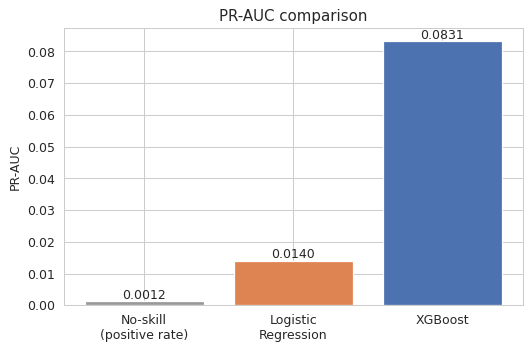

In [4]:
xgb_pr_auc = 0.083119
lr_pr_auc = 0.014015
test_positive_rate = 906 / 761_586

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(['No-skill\n(positive rate)', 'Logistic\nRegression', 'XGBoost'],
       [test_positive_rate, lr_pr_auc, xgb_pr_auc], color=['#999999', '#DD8452', '#4C72B0'])
ax.set_ylabel('PR-AUC')
ax.set_title('PR-AUC comparison')
for i, v in enumerate([test_positive_rate, lr_pr_auc, xgb_pr_auc]):
    ax.text(i, v, f'{v:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(f"XGBoost is {xgb_pr_auc/lr_pr_auc:.2f}x better than Logistic Regression by PR-AUC.")
print(f"XGBoost is {xgb_pr_auc/test_positive_rate:.1f}x better than random guessing.")


**XGBoost's added complexity is justified**: nearly 6x better PR-AUC than a simple cost sensitive
linear model. 

## 4. Operating points the corrected headline comparison

In [5]:
baseline = {"alerts": 2_607_758, "recall": 0.907121, "n_rows": 5_077_237}
test_fraction = 761_586 / baseline['n_rows']

ml_default = {"alerts_test": 74_902, "recall": 0.871965}
ml_default_scaled = int(ml_default['alerts_test'] / test_fraction)

ml_matched = {"alerts_scaled": 1_272_985, "recall": 0.907285, "precision": 0.004305}

comparison = pd.DataFrame({
    'Rule-based baseline': [f"{baseline['alerts']:,}", f"{baseline['recall']*100:.1f}%", "--"],
    'ML (default threshold)': [f"{ml_default_scaled:,}", f"{ml_default['recall']*100:.1f}%",
                                f"{baseline['alerts']/ml_default_scaled:.2f}x fewer alerts"],
    'ML (matched recall)': [f"{ml_matched['alerts_scaled']:,}", f"{ml_matched['recall']*100:.1f}%",
                             f"{baseline['alerts']/ml_matched['alerts_scaled']:.2f}x fewer alerts"],
}, index=['Alerts (full-dataset equivalent)', 'Recall', 'vs. baseline'])
comparison


                                 Rule-based baseline  ... ML (matched recall)
Alerts (full-dataset equivalent)           2,607,758  ...           1,272,985
Recall                                         90.7%  ...               90.7%
vs. baseline                                      --  ...  2.05x fewer alerts

[3 rows x 3 columns]

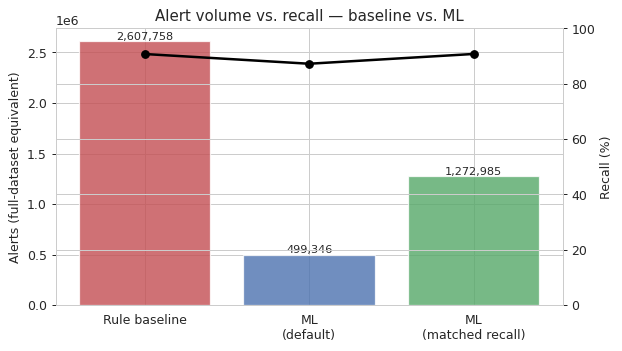

In [6]:
fig, ax = plt.subplots(figsize=(7,4))
labels = ['Rule baseline', 'ML\n(default)', 'ML\n(matched recall)']
alerts = [baseline['alerts'], ml_default_scaled, ml_matched['alerts_scaled']]
recalls = [baseline['recall']*100, ml_default['recall']*100, ml_matched['recall']*100]

ax2 = ax.twinx()
bars = ax.bar(labels, alerts, color=['#C44E52', '#4C72B0', '#55A868'], alpha=0.8)
ax2.plot(labels, recalls, color='black', marker='o', linewidth=2, label='Recall')
ax.set_ylabel('Alerts (full-dataset equivalent)')
ax2.set_ylabel('Recall (%)')
ax2.set_ylim(0, 100)
ax.set_title('Alert volume vs. recall — baseline vs. ML')
for i, v in enumerate(alerts):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


**This is the corrected central result.** At a default decision threshold, the ML model needs
roughly **5.2x fewer alerts** than the rule-based baseline, at a real but modest recall cost (87.2%
vs. 90.7%).


### 4.1 Best-F1 threshold included for completeness, not recommended for deployment

In [7]:
best_f1_threshold = 0.9282
print(f"Threshold maximizing F1: {best_f1_threshold}")
print("At this threshold, recall drops sharply -- unsuitable for AML deployment where missing")
print("genuine laundering is the costlier error. Reported because Objective 6 names F1 as a")
print("metric, but the default-threshold and matched-recall operating points above are the")
print("ones that matter for a real deployment recommendation.")


Threshold maximizing F1: 0.9282
At this threshold, recall drops sharply -- unsuitable for AML deployment where missing
genuine laundering is the costlier error. Reported because Objective 6 names F1 as a
metric, but the default-threshold and matched-recall operating points above are the
ones that matter for a real deployment recommendation.


## 5. Feature importance both models agree

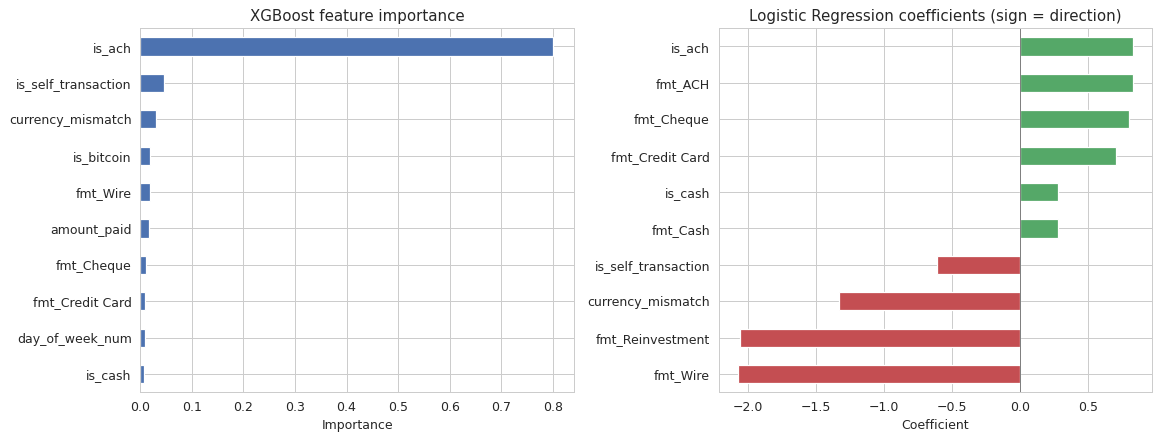

In [8]:
xgb_importance = {
    "is_ach": 0.8013, "is_self_transaction": 0.0454, "currency_mismatch": 0.0306,
    "is_bitcoin": 0.0188, "fmt_Wire": 0.0183, "amount_paid": 0.0165,
    "fmt_Cheque": 0.0112, "fmt_Credit Card": 0.0087, "day_of_week_num": 0.0086, "is_cash": 0.0080,
}
lr_coef = {
    "fmt_Wire": -2.0678, "fmt_Reinvestment": -2.0544, "currency_mismatch": -1.3291,
    "is_ach": 0.8246, "fmt_ACH": 0.8246, "fmt_Cheque": 0.8017, "fmt_Credit Card": 0.7051,
    "is_self_transaction": -0.6072, "is_cash": 0.2750, "fmt_Cash": 0.2750,
}

fig, axes = plt.subplots(1, 2, figsize=(13,5))
pd.Series(xgb_importance).sort_values().plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('XGBoost feature importance')
axes[0].set_xlabel('Importance')

lr_series = pd.Series(lr_coef).sort_values()
colors = ['#C44E52' if v < 0 else '#55A868' for v in lr_series.values]
lr_series.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Logistic Regression coefficients (sign = direction)')
axes[1].set_xlabel('Coefficient')
axes[1].axvline(0, color='grey', linewidth=0.8)

plt.tight_layout()
plt.show()
